# LocoSense — Phase 2: Preprocessing & Feature Engineering

**Input:** `data/processed/locosense_phase1.csv`  
**Output:** `data/processed/train.csv`, `val.csv`, `test.csv`

| Step | Task |
|------|------|
| 1 | Load Phase 1 output |
| 2 | Fix data types |
| 3 | Handle `days_since_service` negatives |
| 4 | Add `loco_age` feature |
| 5 | Rolling features (mean & std, windows 5 & 10) |
| 6 | Lag features (previous cycle sensor values) |
| 7 | One-hot encode `loco_type` and `zone` |
| 8 | Train / Val / Test split (by loco_id) |
| 9 | Normalize sensor columns (MinMaxScaler) |
| 10 | Save outputs + summary |

---
## Cell 1 — Imports

In [1]:
import sys, warnings, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

NOTEBOOK_DIR  = Path().resolve()
ROOT          = NOTEBOOK_DIR
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIGURES_DIR   = ROOT / 'reports' / 'figures'
MODELS_DIR    = ROOT / 'models'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV = PROCESSED_DIR / 'locosense phase1.csv'
assert INPUT_CSV.exists(), f'Run 01_setup_and_eda.ipynb first — {INPUT_CSV} not found.'

SENSOR_COLS = [
    'engine temp   (C)', 'oil pressure (bar)', 'vibration    (mms)', 'fuel efficiency (%)',
    'coolant temp (C)', 'bearing temp  (C)', 'RPM', 'exhaust temp (C)',
    'turbo pressure (bar)', 'load factor (%)', 'battery voltage (V)', 'brake pressure (bar)',
]

print(f'Python  : {sys.version.split()[0]}')
print(f'pandas  : {pd.__version__}')
print(f'sklearn : {__import__("sklearn").__version__}')
print('Imports OK ✓')

Python  : 3.9.6
pandas  : 2.3.3
sklearn : 1.6.1
Imports OK ✓


---
## Cell 2 — Load Phase 1 output

In [2]:
df_raw = pd.read_csv(INPUT_CSV)
print(f'Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Locos: {df_raw["loco id"].nunique()}')
df_raw.head(3)

Loaded: 6,925 rows x 22 columns
Locos: 50


,loco id,loco type,zone,manufacture year,cycle,totalcycles,days since service,engine temp (C),oil pressure (bar),vibration (mms),...,bearing temp (C),RPM,exhaust temp (C),turbo pressure (bar),load factor (%),battery voltage (V),brake pressure (bar),RU,failure label,risk category
0,WDG4-1001,WDG4,NR,2014,1,174,-12,78.563,3.379,1.993,...,59.894,917.562,323.872,2.033,76.166,24.098,4.137,173,0,Low
1,WDG4-1001,WDG4,NR,2014,2,174,-10,83.015,3.785,2.354,...,59.337,913.649,325.032,1.775,70.422,23.585,3.951,172,0,Low
2,WDG4-1001,WDG4,NR,2014,3,174,-8,81.256,3.553,1.808,...,63.438,881.074,318.182,1.891,64.320,24.109,4.280,171,0,Low


---
## Cell 3 — Fix data types

In [3]:
df_raw['failure label']    = df_raw['failure label'].astype(int)
df_raw['manufacture year'] = df_raw['manufacture year'].astype(int)
df_raw['cycle']            = df_raw['cycle'].astype(int)
df_raw['totalcycles']     = df_raw['totalcycles'].astype(int)

RISK_MAP = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
df_raw['risk encoded'] = df_raw['risk category'].map(RISK_MAP)

print('Dtypes fixed:')
for col in ['failure label', 'manufacture year', 'cycle', 'totalcycles', 'risk encoded']:
    print(f'  {col:<22} {df_raw[col].dtype}')
print('\nfailure label distribution:')
print(df_raw['failure label'].value_counts().to_string())

Dtypes fixed:
  failure label          int64
  manufacture year       int64
  cycle                  int64
  totalcycles            int64
  risk encoded           int64

failure label distribution:
failure label
0    5375
1    1550


---
## Cell 4 — Handle `days_since_service` negatives

441 rows have negative values (range -38 to 0). Decision: keep as-is — negatives represent days *before* next scheduled service, which is genuine signal.

Negative rows : 441
Range         : -38 to 180
Decision      : KEEP negatives (pre-service window signal)


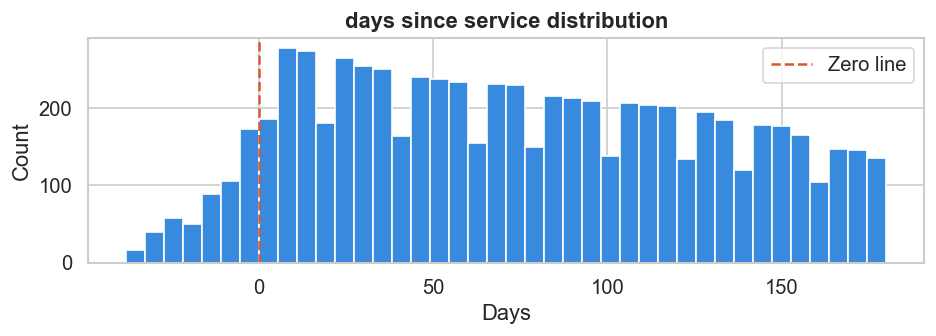

In [4]:
neg_count = (df_raw['days since service'] < 0).sum()
print(f'Negative rows : {neg_count}')
print(f'Range         : {df_raw["days since service"].min():.0f} to {df_raw["days since service"].max():.0f}')
print('Decision      : KEEP negatives (pre-service window signal)')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df_raw['days since service'], bins=40, color='#378ADD', edgecolor='white')
ax.axvline(0, color='#D85A30', linestyle='--', linewidth=1.5, label='Zero line')
ax.set_title('days since service distribution', fontweight='bold')
ax.set_xlabel('Days')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'days since service dist.png')
plt.show()

---
## Cell 5 — Add `loco_age` feature

In [5]:
CURRENT_YEAR = 2024
df_raw['loco age'] = CURRENT_YEAR - df_raw['manufacture year']
print('loco age stats:')
print(df_raw['loco age'].describe().round(1).to_string())
print()
print(df_raw[['loco id','manufacture year','loco age']].drop_duplicates('loco id').head(5).to_string(index=False))

loco age stats:
count    6925.0
mean        9.0
std         3.4
min         4.0
25%         6.0
50%         9.0
75%        12.0
max        14.0

  loco id  manufacture year  loco age
WDG4-1001              2014        10
WAP7-1002              2011        13
WDG4-1003              2010        14
WDG4-1004              2018         6
WDG4-1005              2020         4


---
## Cell 6 — Rolling features (windows 5 & 10 cycles)

Rolling mean and std capture sensor *trends* over time — biggest accuracy booster for predictive maintenance. Computed per loco so values never bleed across locomotives.

In [6]:
print(df_raw.columns.tolist())

['loco id', 'loco type', 'zone', 'manufacture year', 'cycle', 'totalcycles', 'days since service', 'engine temp   (C)', 'oil pressure (bar)', 'vibration    (mms)', 'fuel efficiency (%)', 'coolant temp (C)', 'bearing temp  (C)', 'RPM', 'exhaust temp (C)', 'turbo pressure (bar)', 'load factor (%)', 'battery voltage (V)', 'brake pressure (bar)', 'RU', 'failure label', 'risk category', 'risk encoded', 'loco age']


In [7]:
df_raw = df_raw.sort_values(['loco id', 'cycle']).reset_index(drop=True)

WINDOWS = [5, 10]
rolling_cols_added = []

for window in WINDOWS:
    for sensor in SENSOR_COLS:
        mean_col = f'{sensor}_roll{window}_mean'
        std_col  = f'{sensor}_roll{window}_std'
        grp = df_raw.groupby('loco id')[sensor]
        df_raw[mean_col] = grp.transform(lambda x: x.rolling(window, min_periods=1).mean())
        df_raw[std_col]  = grp.transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
        rolling_cols_added.extend([mean_col, std_col])

print(f'Rolling features added : {len(rolling_cols_added)}')
print(f'  ({len(SENSOR_COLS)} sensors x {len(WINDOWS)} windows x 2 stats)')
print(f'Total columns now      : {df_raw.shape[1]}')

sample_loco = df_raw['loco id'].iloc[0]
print(f'\nSample loco {sample_loco} — first 5 cycles:')
print(df_raw[df_raw['loco id']==sample_loco][['cycle','engine temp   (C)','engine temp   (C)_roll5_std','engine temp   (C)_roll5_mean']].head(5).to_string(index=False))

Rolling features added : 48
  (12 sensors x 2 windows x 2 stats)
Total columns now      : 72

Sample loco WAG9-1006 — first 5 cycles:
 cycle  engine temp   (C)  engine temp   (C)_roll5_std  engine temp   (C)_roll5_mean
     1             86.259                     0.000000                      86.25900
     2             84.101                     1.525936                      85.18000
     3             81.694                     2.283632                      84.01800
     4             83.031                     1.928780                      83.77125
     5             81.834                     1.881683                      83.38380


---
## Cell 7 — Lag features (1 cycle back)

In [8]:
lag_cols_added = []
for sensor in SENSOR_COLS:
    lag_col = f'{sensor}_lag1'
    df_raw[lag_col] = df_raw.groupby('loco id')[sensor].transform(lambda x: x.shift(1))
    df_raw[lag_col] = df_raw[lag_col].fillna(df_raw[sensor])
    lag_cols_added.append(lag_col)

print(f'Lag features added : {len(lag_cols_added)}')
print(f'Total columns now  : {df_raw.shape[1]}')
print(f'Null check         : {df_raw[lag_cols_added].isnull().sum().sum()} nulls')

print(f'\nSample loco {sample_loco} — first 4 cycles:')
print(df_raw[df_raw['loco id']==sample_loco][['cycle','engine temp   (C)','engine temp   (C)_lag1']].head(4).to_string(index=False))

Lag features added : 12
Total columns now  : 84
Null check         : 0 nulls

Sample loco WAG9-1006 — first 4 cycles:
 cycle  engine temp   (C)  engine temp   (C)_lag1
     1             86.259                  86.259
     2             84.101                  86.259
     3             81.694                  84.101
     4             83.031                  81.694


---
## Cell 8 — One-hot encode `loco_type` and `zone`

In [9]:
df_raw = pd.get_dummies(df_raw, columns=['loco type', 'zone'], drop_first=False, dtype=int)
new_ohe_cols = [c for c in df_raw.columns if c.startswith('loco_type_') or c.startswith('zone_')]
print(f'One-hot columns added : {len(new_ohe_cols)}')
for c in new_ohe_cols:
    print(f'  {c}  (sum={df_raw[c].sum()})')
print(f'\nTotal columns now : {df_raw.shape[1]}')

One-hot columns added : 5
  zone_CR  (sum=1282)
  zone_ER  (sum=2043)
  zone_NR  (sum=1639)
  zone_SR  (sum=715)
  zone_WR  (sum=1246)

Total columns now : 92


---
## Cell 9 — Train / Val / Test split by loco_id

**Why by loco_id?** Splitting randomly lets cycles from the same loco appear in train AND test — model memorises loco-specific patterns, accuracy looks inflated. Split by loco = true out-of-sample test.

| Split | Locos | % |
|-------|-------|---|
| Train | 35 | 70% |
| Val | 7 | 15% |
| Test | 8 | 15% |

In [10]:
random.seed(42)
all_locos = df_raw['loco id'].unique().tolist()
random.shuffle(all_locos)

n_total = len(all_locos)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)

train_locos = all_locos[:n_train]
val_locos   = all_locos[n_train : n_train + n_val]
test_locos  = all_locos[n_train + n_val :]

train_df_raw = df_raw[df_raw['loco id'].isin(train_locos)].copy()
val_df_raw   = df_raw[df_raw['loco id'].isin(val_locos)].copy()
test_df_raw  = df_raw[df_raw['loco id'].isin(test_locos)].copy()
print(f'Train : {len(train_locos)} locos  {len(train_df_raw):,} rows  {train_df_raw["failure label"].mean()*100:.1f}% failure')
print(f'Val   : {len(val_locos)} locos   {len(val_df_raw):,} rows  {val_df_raw["failure label"].mean()*100:.1f}% failure')
print(f'Test  : {len(test_locos)} locos   {len(test_df_raw):,} rows  {test_df_raw["failure label"].mean()*100:.1f}% failure')

assert not set(train_locos) & set(val_locos)
assert not set(train_locos) & set(test_locos)
assert not set(val_locos)   & set(test_locos)
print('\nNo loco leaks across splits ✓')

Train : 35 locos  4,979 rows  21.8% failure
Val   : 7 locos   802 rows  27.1% failure
Test  : 8 locos   1,144 rows  21.7% failure

No loco leaks across splits ✓


---
## Cell 10 — Normalize with MinMaxScaler

Fit on **train only** — transform val & test. Fitting on all data leaks test distribution into training.

In [11]:
scale_cols = SENSOR_COLS + rolling_cols_added + lag_cols_added + ['loco age', 'days since service']
# NOTE: 'ru' is intentionally excluded from scaling too — it's no longer
# a model feature (see DROP_COLS below), so it stays in its original
# units (cycles remaining) for clean display and risk bucketing.

scaler = MinMaxScaler()
train_df_raw[scale_cols] = scaler.fit_transform(train_df_raw[scale_cols])
val_df_raw[scale_cols]   = scaler.transform(val_df_raw[scale_cols])
test_df_raw[scale_cols]  = scaler.transform(test_df_raw[scale_cols])

joblib.dump(scaler, MODELS_DIR / 'scaler.pkl')
print(f'Scaled {len(scale_cols)} columns')
print(f'Scaler saved → models/scaler.pkl')
print()
print('Train sensor range after scaling (expect 0.0 – 1.0):')
print(train_df_raw[SENSOR_COLS].agg(['min','max']).round(3).to_string())

Scaled 74 columns
Scaler saved → models/scaler.pkl

Train sensor range after scaling (expect 0.0 – 1.0):
     engine temp   (C)  oil pressure (bar)  vibration    (mms)  fuel efficiency (%)  coolant temp (C)  bearing temp  (C)  RPM  exhaust temp (C)  turbo pressure (bar)  load factor (%)  battery voltage (V)  brake pressure (bar)
min                0.0                 0.0                 0.0                  0.0               0.0                0.0  0.0               0.0                   0.0              0.0                  0.0                   0.0
max                1.0                 1.0                 1.0                  1.0               1.0                1.0  1.0               1.0                   1.0              1.0                  1.0                   1.0


---
## Cell 11 — Define final feature set

In [12]:
df_raw['degradation'] = (1 - (df_raw['RU'] / df_raw['totalcycles'])).clip(0, 1)
train_df_raw['degradation'] = (1 - (train_df_raw['RU'] / train_df_raw['totalcycles'])).clip(0, 1)
val_df_raw['degradation']   = (1 - (val_df_raw['RU']   / val_df_raw['totalcycles'])).clip(0, 1)
test_df_raw['degradation']  = (1 - (test_df_raw['RU']  / test_df_raw['totalcycles'])).clip(0, 1)

DROP_COLS   = ['loco id','manufacture year','risk category','risk encoded',
               'total cycles','ru','failure label']
TARGET_COL  = 'degradation'
FEATURE_COLS = [c for c in train_df_raw.columns if c not in DROP_COLS + [TARGET_COL]]


print(f'Feature columns : {len(FEATURE_COLS)}')
print(f'Target: {TARGET_COL}')
print()
print(f'  Raw sensor: {len(SENSOR_COLS)}')
print(f'  Rolling features : {len(rolling_cols_added)}')
print(f'  Lag features : {len(lag_cols_added)}')
print(f'  One-hot (type+zone) : {len(new_ohe_cols)}')
other = len(FEATURE_COLS) - len(SENSOR_COLS) - len(rolling_cols_added) - len(lag_cols_added) - len(new_ohe_cols)
print(f'  Other (age, days..) : {other}')

scale_pos_weight = 1.0
print(f'\nTarget: degradation (continuous 0.0–1.0)')
print(f'Mean degradation train: {train_df_raw[TARGET_COL].mean():.3f}')

Feature columns : 87
Target: degradation

  Raw sensor: 12
  Rolling features : 48
  Lag features : 12
  One-hot (type+zone) : 5
  Other (age, days..) : 10

Target: degradation (continuous 0.0–1.0)
Mean degradation train: 0.504


---
## Cell 12 — Feature correlation with failure label

In [13]:
print(train_df_raw.columns.tolist())

['loco id', 'manufacture year', 'cycle', 'totalcycles', 'days since service', 'engine temp   (C)', 'oil pressure (bar)', 'vibration    (mms)', 'fuel efficiency (%)', 'coolant temp (C)', 'bearing temp  (C)', 'RPM', 'exhaust temp (C)', 'turbo pressure (bar)', 'load factor (%)', 'battery voltage (V)', 'brake pressure (bar)', 'RU', 'failure label', 'risk category', 'risk encoded', 'loco age', 'engine temp   (C)_roll5_mean', 'engine temp   (C)_roll5_std', 'oil pressure (bar)_roll5_mean', 'oil pressure (bar)_roll5_std', 'vibration    (mms)_roll5_mean', 'vibration    (mms)_roll5_std', 'fuel efficiency (%)_roll5_mean', 'fuel efficiency (%)_roll5_std', 'coolant temp (C)_roll5_mean', 'coolant temp (C)_roll5_std', 'bearing temp  (C)_roll5_mean', 'bearing temp  (C)_roll5_std', 'RPM_roll5_mean', 'RPM_roll5_std', 'exhaust temp (C)_roll5_mean', 'exhaust temp (C)_roll5_std', 'turbo pressure (bar)_roll5_mean', 'turbo pressure (bar)_roll5_std', 'load factor (%)_roll5_mean', 'load factor (%)_roll5_std', 

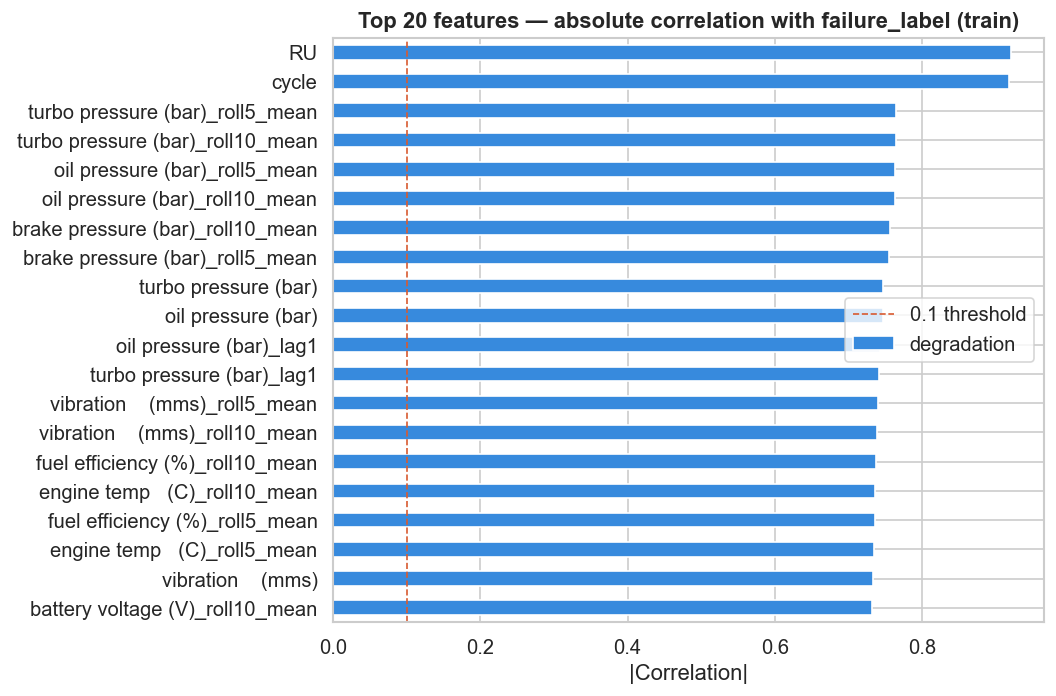

In [14]:
corr_with_target = (
    train_df_raw[FEATURE_COLS + [TARGET_COL]]
    .corr()[TARGET_COL].drop(TARGET_COL)
    .abs().sort_values(ascending=False).head(20)
)

fig, ax = plt.subplots(figsize=(9, 6))
corr_with_target.sort_values().plot.barh(ax=ax, color='#378ADD')
ax.set_title('Top 20 features — absolute correlation with failure_label (train)', fontweight='bold')
ax.set_xlabel('|Correlation|')
ax.axvline(0.1, color='#D85A30', linestyle='--', linewidth=1, label='0.1 threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature correlations.png')
plt.show()

---
## Cell 13 — Save all outputs

In [15]:
train_df_raw.to_csv(PROCESSED_DIR / 'train.csv', index=False)
val_df_raw.to_csv(PROCESSED_DIR   / 'val.csv',   index=False)
test_df_raw.to_csv(PROCESSED_DIR  / 'test.csv',  index=False)

meta = {
    'feature_cols'     : FEATURE_COLS,
    'target_col'       : TARGET_COL,
    'sensor_cols'      : SENSOR_COLS,
    'scale_pos_weight' : scale_pos_weight,
    'train_locos'      : train_locos,
    'val_locos'        : val_locos,
    'test_locos'       : test_locos,
}
with open(PROCESSED_DIR / 'preprocessing_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
print(f'  data/processed/train.csv               {len(train_df_raw):,} rows')
print(f'  data/processed/val.csv                 {len(val_df_raw):,} rows')
print(f'  data/processed/test.csv                {len(test_df_raw):,} rows')
print(f'  data/processed/preprocessing_meta.json')
print(f'  models/scaler.pkl')

Saved:
  data/processed/train.csv               4,979 rows
  data/processed/val.csv                 802 rows
  data/processed/test.csv                1,144 rows
  data/processed/preprocessing_meta.json
  models/scaler.pkl


---
## Cell 14 — Phase 2 summary

In [16]:
print(f'  Final feature count: {len(FEATURE_COLS)}')
print()
print('  Features added:')
print(f'loco_age: 1')
print(f'Rolling (5+10 win): {len(rolling_cols_added)}')
print(f'Lag (1 cycle) : {len(lag_cols_added)}')
print(f'One-hot encoded : {len(new_ohe_cols)}')
print()
print('  Splits (no loco leakage):')
print(f' Train  {len(train_locos)} locos  {len(train_df_raw):,} rows  {train_df_raw[TARGET_COL].mean()*100:.1f}% failure')
print(f' Val    {len(val_locos)} locos   {len(val_df_raw):,} rows  {val_df_raw[TARGET_COL].mean()*100:.1f}% failure')
print(f' Test   {len(test_locos)} locos   {len(test_df_raw):,} rows  {test_df_raw[TARGET_COL].mean()*100:.1f}% failure')
print()
print(f'scale_pos_weight: {scale_pos_weight} used in XGBoost')

  Final feature count: 87

  Features added:
loco_age: 1
Rolling (5+10 win): 48
Lag (1 cycle) : 12
One-hot encoded : 5

  Splits (no loco leakage):
 Train  35 locos  4,979 rows  50.4% failure
 Val    7 locos   802 rows  50.4% failure
 Test   8 locos   1,144 rows  50.3% failure

scale_pos_weight: 1.0 used in XGBoost
